In [98]:
import os
import re
import numpy as np
from collections import Counter
from datasets import load_dataset
import matplotlib.pyplot as plt

from tokenizers import Tokenizer, normalizers, decoders
from tokenizers.models import WordLevel, BPE
from tokenizers.trainers import WordLevelTrainer, BpeTrainer
from tokenizers.pre_tokenizers import Whitespace, ByteLevel

from tqdm.notebook import tqdm

In [68]:
os.environ["TOKENIZERS_PARALLELISM"] = "true"

from transformers import logging
logging.enable_progress_bar()
logging.set_verbosity_info()

In [87]:
ds = load_dataset("cfilt/iitb-english-hindi", split="train")
#ds = ds.select(range(160000))

In [88]:
def get_unique_words(ds,lang):
    words = []
    unique_words = set()
    for sent in tqdm(ds['translation'][lang]):
        if lang == 'en':
            sent = re.sub(r'[^\w\s]','',sent).lower().split()
        else: 
            sent = re.findall(r'[\u0900-\u097F]+', sent)
        #sent = re.sub(r'[\u0964\u0965]', '', sent)  # । ॥ Devanagari danda
        unique_words.update(sent)
        words.extend(sent)   
    return unique_words, Counter(words)

In [89]:
unique_words_en, count_en = get_unique_words(ds,'en')
unique_words_hi, count_hi = get_unique_words(ds,'hi')

  0%|          | 0/1659083 [00:00<?, ?it/s]

  0%|          | 0/1659083 [00:00<?, ?it/s]

In [90]:
less_count_en = [word for word, count in count_en.items() if count <= 5]
less_count_hi = [word for word, count in count_hi.items() if count <= 5]

In [91]:
len(less_count_en), len(less_count_hi)

(162467, 255580)

In [92]:
len(unique_words_en), len(unique_words_hi)

(223488, 332242)

In [93]:
en_count = np.array(list(count_en.values()))
hi_count = np.array(list(count_hi.values()))

In [ ]:
#mean count of words in both languages
en_count.mean(), hi_count.mean()

(np.float64(95.28517862256587), np.float64(69.26138778360352))

In [95]:
en_count.std(), hi_count.std()

(np.float64(4261.690416244992), np.float64(2970.882539475021))

In [ ]:
#median count of words in both languages
np.median(en_count), np.median(hi_count)

(np.float64(2.0), np.float64(2.0))

(9819, 11727) for first 160k data samples

4242, 5607 less counts

(76.38191261839292, 62.66266538158241)# avg count

620.3134682092634, 514.7937397836482 #std

8, 6 #meadian 

In [107]:
count_en.most_common(10), count_hi.most_common(10)

([('the', 1313578),
  ('of', 805302),
  ('and', 663974),
  ('to', 528708),
  ('in', 428522),
  ('a', 376097),
  ('is', 306206),
  ('for', 209127),
  ('that', 189476),
  ('you', 174686)],
 [('के', 865995),
  ('और', 593340),
  ('में', 575665),
  ('है', 500712),
  ('की', 486451),
  ('से', 392518),
  ('को', 349356),
  ('का', 310396),
  ('है।', 219634),
  ('कि', 205975)])

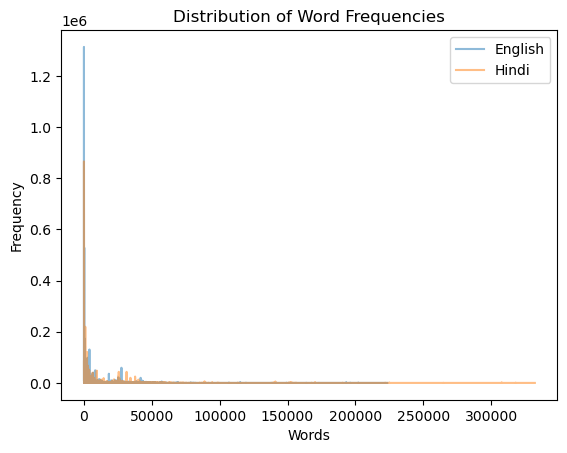

In [111]:
plt.plot(en_count, label='English', alpha=0.5)
plt.plot(hi_count, label='Hindi', alpha=0.5)
plt.xlabel('Words')
#plt.yscale('log')
plt.ylabel('Frequency')
plt.title('Distribution of Word Frequencies')
plt.legend()
plt.show()

In [97]:
len(set(unique_words_en).intersection(set(unique_words_hi)))

471